# ___Species coverage in FRED subset___
----------------------------------------------

In [1]:
!python --version

Python 3.13.9


The system cannot find the path specified.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
theplantlist_06_2025 = pd.read_csv(r"../../data/chapter2/wfotpl_06_2025.csv", low_memory=False, sep='\t', encoding="latin1")
subset_categorical = pd.read_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_categorical.csv")
subset_collab_categorical = pd.read_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_collab_categorical.csv")

In [5]:
theplantlist_06_2025.query(r"taxonRank=='species' & taxonomicStatus=='Accepted'")

,taxonID,scientificNameID,localID,scientificName,taxonRank,parentNameUsageID,scientificNameAuthorship,family,subfamily,tribe,...,acceptedNameUsageID,originalNameUsageID,nameAccordingToID,taxonRemarks,created,modified,references,source,majorGroup,tplID
5,wfo-0001302015,NaN,9905399,Fimbristylis schulzii,species,wfo-4000014776,Boeck.,Cyperaceae,NaN,Abildgaardieae,...,NaN,NaN,NaN,Source in seed data: tro More details could be...,2022-04-16,2025-06-12,https://www.cyperaceae.org/aphia.php?p=taxdeta...,The Cyperaceae TEN,A,tro-9905399
12,wfo-0001302022,urn:lsid:ipni.org:names:301711-1,9905507,Carex Ã prolixa,species,wfo-1000081875,Fr.,Cyperaceae,NaN,Cariceae,...,NaN,NaN,NaN,Source in seed data: tro Update namepublishedI...,2022-04-16,2025-06-12,https://www.cyperaceae.org/aphia.php?p=taxdeta...,The Cyperaceae TEN,A,tro-9905507
21,wfo-0001302031,urn:lsid:ipni.org:names:77099091-1,9905591,Carex Ã descendens,species,wfo-4000006709,KÃ¼k.,Cyperaceae,NaN,Cariceae,...,NaN,NaN,NaN,Source in seed data: tro Update namepublishedI...,2022-04-16,2025-06-12,https://www.cyperaceae.org/aphia.php?p=taxdeta...,The Cyperaceae TEN,A,tro-9905591
29,wfo-0001302040,urn:lsid:ipni.org:names:300004-1,9905643,Carex Ã grahamii,species,wfo-4000006709,Boott,Cyperaceae,NaN,Cariceae,...,NaN,NaN,NaN,Source in seed data: tro Update namepublishedI...,2022-04-16,2025-06-12,https://www.cyperaceae.org/aphia.php?p=taxdeta...,The Cyperaceae TEN,A,tro-9905643
32,wfo-0001302043,NaN,9905692,Carex krascheninnikowii,species,wfo-4000006709,Kom. ex V.Krecz.,Cyperaceae,NaN,Cariceae,...,NaN,NaN,NaN,Source in seed data: tro More details could be...,2022-04-16,2025-06-12,https://www.cyperaceae.org/aphia.php?p=taxdeta...,The Cyperaceae TEN,A,tro-9905692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1648170,wfo-1000081933,NaN,NaN,Sideroxylon alachuense,species,wfo-4000035327,L.C.Anderson,Sapotaceae,NaN,NaN,...,NaN,wfo-0000668631,NaN,NaN,2025-06-13,2025-06-16,https://powo.science.kew.org/taxon/urn:lsid:ip...,The Sapotaceae TEN,A,NaN
1648179,wfo-1000081937,NaN,NaN,Chrysophyllum pubipetalum,species,wfo-4000008232,Sossai & Alves-AraÃºjo,Sapotaceae,NaN,NaN,...,NaN,NaN,NaN,NaN,2025-06-13,2025-06-16,https://powo.science.kew.org/taxon/urn:lsid:ip...,The Sapotaceae TEN,A,NaN
1648180,wfo-1000081938,NaN,NaN,Chrysophyllum sierpense,species,wfo-4000008232,"Aguilar, D.Santam. & J.M.Chaves",Sapotaceae,NaN,NaN,...,NaN,NaN,NaN,NaN,2025-06-13,2025-06-16,https://powo.science.kew.org/taxon/urn:lsid:ip...,The Sapotaceae TEN,A,NaN
1648181,wfo-1000081939,NaN,NaN,Chrysophyllum moralesianum,species,wfo-4000008232,"Aguilar, D.Santam. & J.M.Chaves",Sapotaceae,NaN,NaN,...,NaN,NaN,NaN,NaN,2025-06-13,2025-06-16,https://powo.science.kew.org/taxon/urn:lsid:ip...,The Sapotaceae TEN,A,NaN


In [7]:
theplantlist_06_2025.columns

Index(['taxonID', 'scientificNameID', 'localID', 'scientificName', 'taxonRank',
       'parentNameUsageID', 'scientificNameAuthorship', 'family', 'subfamily',
       'tribe', 'subtribe', 'genus', 'subgenus', 'specificEpithet',
       'infraspecificEpithet', 'verbatimTaxonRank', 'nomenclaturalStatus',
       'namePublishedIn', 'taxonomicStatus', 'acceptedNameUsageID',
       'originalNameUsageID', 'nameAccordingToID', 'taxonRemarks', 'created',
       'modified', 'references', 'source', 'majorGroup', 'tplID'],
      dtype='object')

In [10]:
# filter for species (excluding subspecies etc...) and accepted species names
tpl_species_list = theplantlist_06_2025.query(r"taxonRank=='species' & taxonomicStatus=='Accepted'").loc[:, ["family", "genus", "specificEpithet", "taxonomicStatus"]]
tpl_species_list.loc[:, "genus"] = tpl_species_list.genus.str.strip()
tpl_species_list.loc[:, "specificEpithet"] = tpl_species_list.specificEpithet.str.strip()

tpl_species_list.drop_duplicates(inplace=True)
tpl_species_list.reset_index(drop=True, inplace=True)
tpl_species_list

,family,genus,specificEpithet,taxonomicStatus
0,Cyperaceae,Fimbristylis,schulzii,Accepted
1,Cyperaceae,Carex,prolixa,Accepted
2,Cyperaceae,Carex,descendens,Accepted
3,Cyperaceae,Carex,grahamii,Accepted
4,Cyperaceae,Carex,krascheninnikowii,Accepted
...,...,...,...,...
379005,Sapotaceae,Sideroxylon,alachuense,Accepted
379006,Sapotaceae,Chrysophyllum,pubipetalum,Accepted
379007,Sapotaceae,Chrysophyllum,sierpense,Accepted
379008,Sapotaceae,Chrysophyllum,moralesianum,Accepted


In [25]:
tpl_species_count_per_genus = tpl_species_list.genus.value_counts(sort=False)
# number of species in each genus
tpl_species_count_per_genu.to_csv(r"../../data/chapter2/wfotpl_06_2025_species_count_per_genus.csv", index=True) # genus names are the indices so we want them here!

In [14]:
# now figure out what % of species our FRED subsets actually cover

In [23]:
subset_categorical_freq = subset_categorical.loc[:, ["F01286", "F01287"]].drop_duplicates().F01286.value_counts()
subset_categorical_freq

F01286
Magnolia         23
Acer              8
Quercus           6
Populus           5
Fraxinus          4
                 ..
Rhodoleia         1
Dicranopteris     1
Cunninghamia      1
Carya             1
Pleioblastus      1
Name: count, Length: 121, dtype: int64

In [31]:
subset_coverage = pd.merge(left=subset_categorical_freq, left_index=True, right=tpl_species_count_per_genus, right_index=True, how="left", suffixes=("_FRED", "_TPL"))
subset_coverage

,count_FRED,count_TPL
F01286,,
Magnolia,23,365.0
Acer,8,167.0
Quercus,6,624.0
Populus,5,98.0
Fraxinus,4,63.0
...,...,...
Rhodoleia,1,6.0
Dicranopteris,1,28.0
Cunninghamia,1,2.0


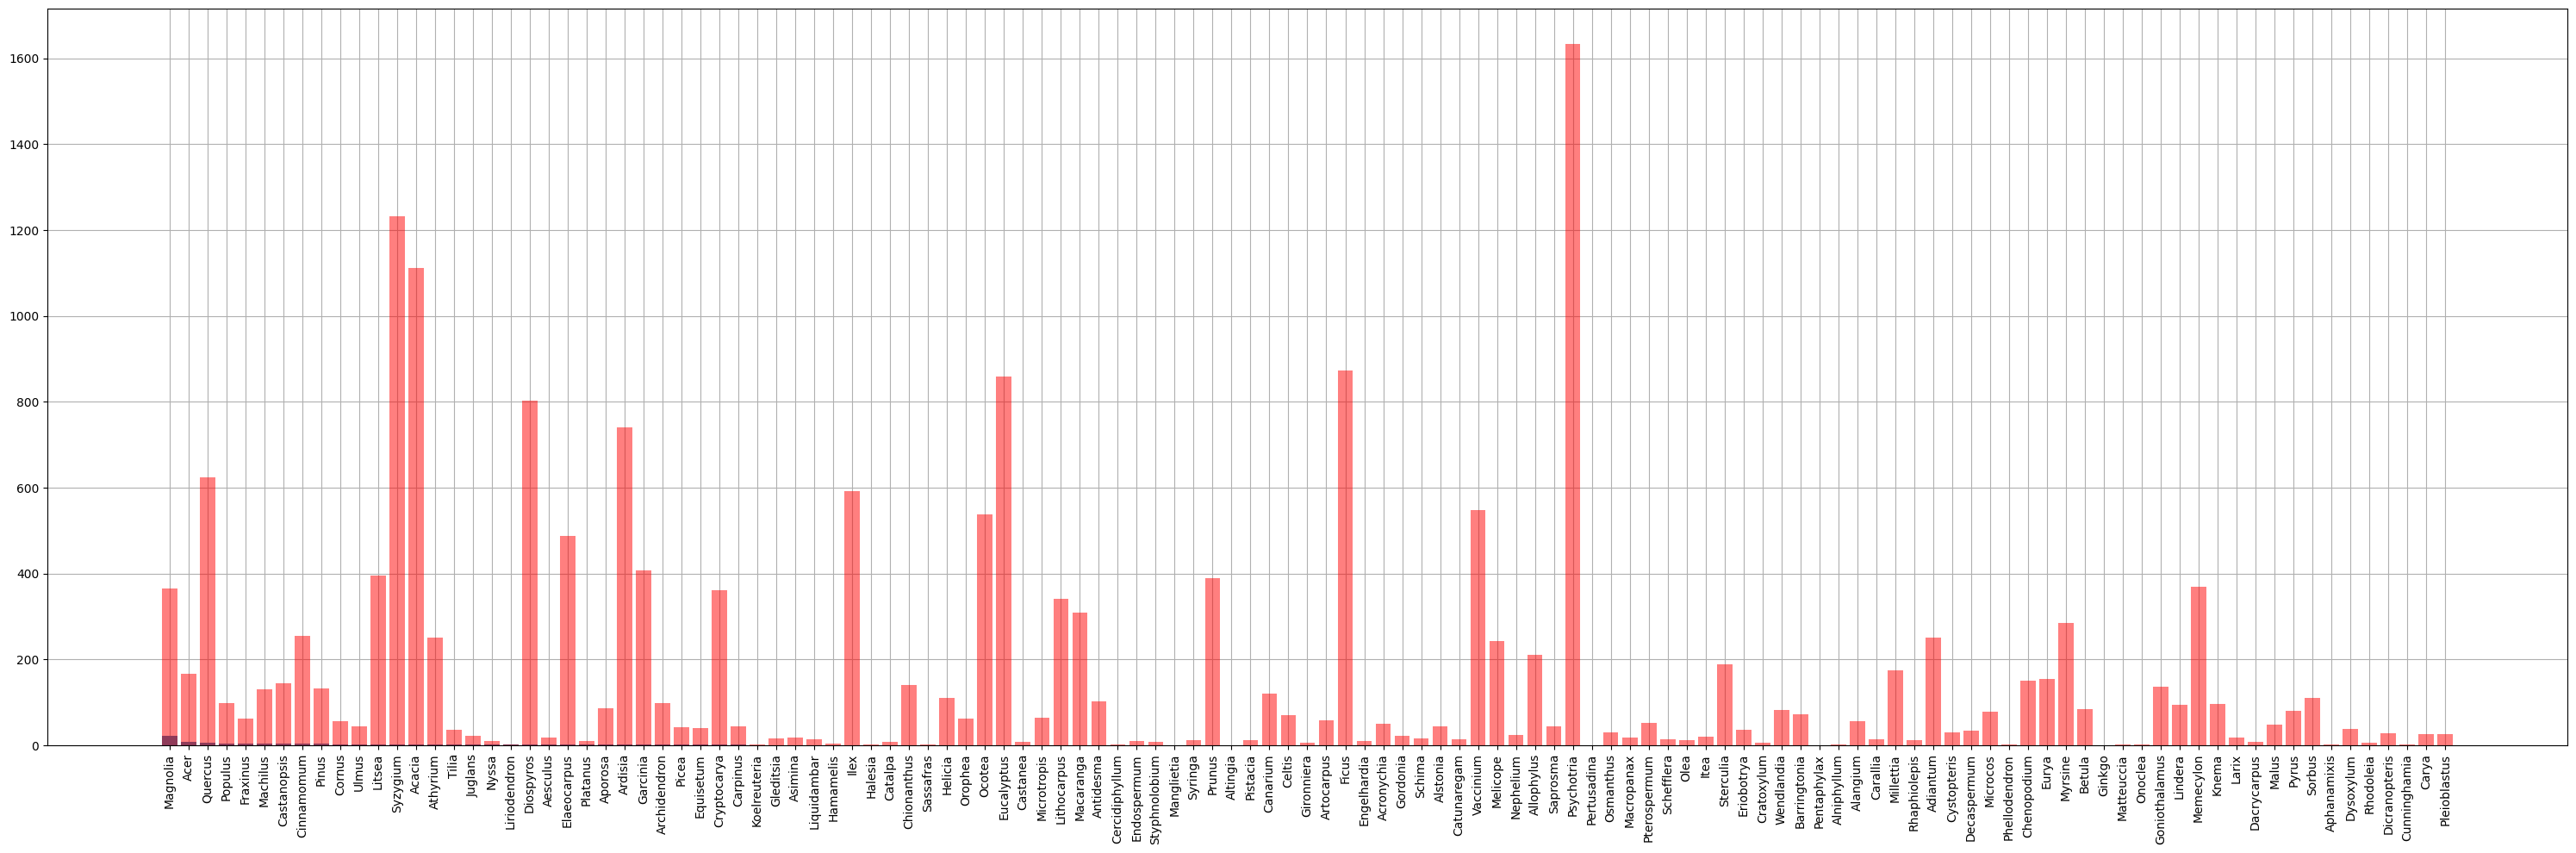

In [46]:
fig, axes = plt.subplots()
fig.set_size_inches(30, 10)
axes.bar(x=subset_coverage.index, height=subset_coverage.count_FRED)
axes.bar(x=subset_coverage.index, height=subset_coverage.count_TPL, color="red", alpha=0.5)
axes.grid()
axes.set_axisbelow(True)
axes.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [27]:
subset_collab_categorical_freq = subset_collab_categorical.loc[:, ["F01286", "F01287"]].drop_duplicates().F01286.value_counts()
subset_collab_categorical_freq

F01286
Magnolia       24
Acer           16
Pinus          12
Quercus        11
Castanopsis     8
               ..
Crataegus       1
Duchesnea       1
Adina           1
Thalictrum      1
Lamium          1
Name: count, Length: 211, dtype: int64

In [32]:
subset_collab_coverage = pd.merge(left=subset_collab_categorical_freq, left_index=True, right=tpl_species_count_per_genus, right_index=True, how="left", suffixes=("_FRED", "_TPL"))
subset_collab_coverage

,count_FRED,count_TPL
F01286,,
Magnolia,24,365.0
Acer,16,167.0
Pinus,12,133.0
Quercus,11,624.0
Castanopsis,8,145.0
...,...,...
Crataegus,1,277.0
Duchesnea,1,NaN
Adina,1,12.0


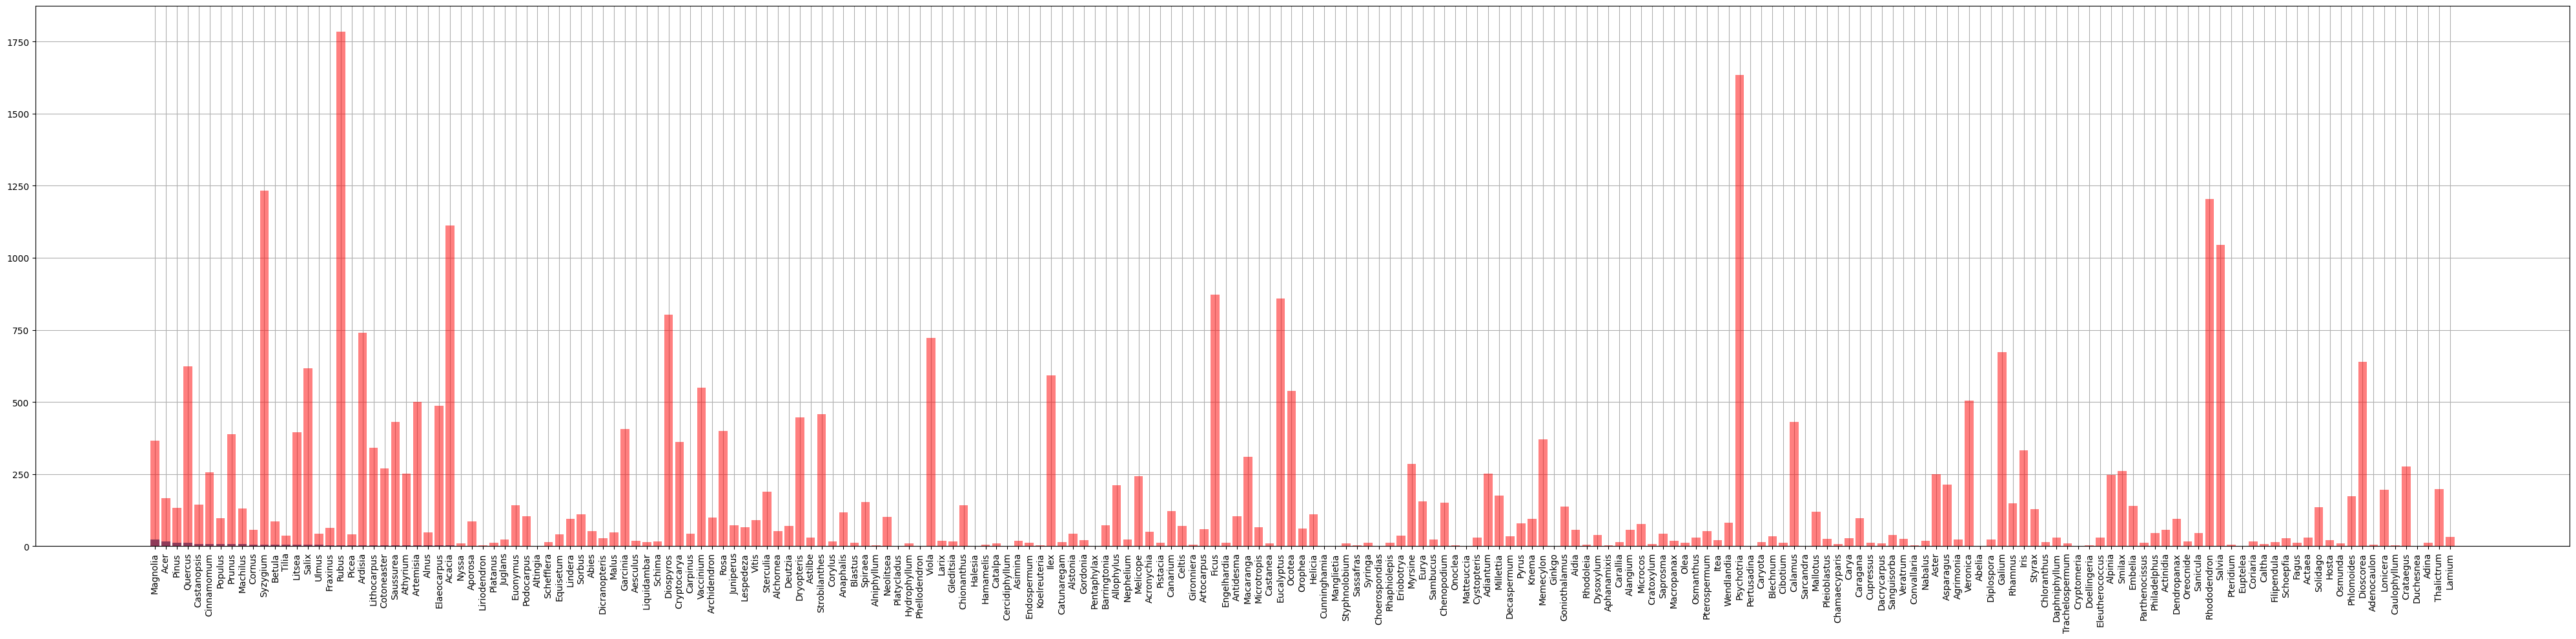

In [45]:
fig, axes = plt.subplots()
fig.set_size_inches(40, 10)
axes.bar(x=subset_collab_coverage.index, height=subset_collab_coverage.count_FRED)
axes.bar(x=subset_collab_coverage.index, height=subset_collab_coverage.count_TPL, color="red", alpha=0.5)
axes.grid()
axes.set_axisbelow(True)
axes.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()